In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# --- Global plot theme ---
sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 12,
    "axes.labelcolor": "#333333",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "axes.edgecolor": "#AAAAAA",
    "grid.color": "#EEEEEE",
    "grid.linewidth": 0.8,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

In [2]:
## READING DATA
data_dir = Path("data")

dfs = []
for csv_file in data_dir.glob("*.csv"):
    df = pd.read_csv(csv_file)
    df["_source_file"] = csv_file.name  # optional: track which file each row came from
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(dfs)} files → {combined.shape[0]} rows, {combined.shape[1]} columns")

Loaded 10 files → 22218 rows, 8 columns


In [3]:
# CLEANING

# combined df keeps players with 0 or 1 year of experience, rookies are considered to have 0 years of experience
# separates by seasons
combined.loc[combined['Experience'] == 'Rook', 'Experience'] = '0'
combined['Experience'] = combined['Experience'].astype(int)
combined = combined[(combined['Experience'] == 0) | (combined['Experience'] == 1)]

# summed_av is the sum of AV for each player across all seasons, so we can see how much AV a player has accumulated in their first two seasons
summed_av = combined.groupby('Player')['AV'].sum().reset_index()

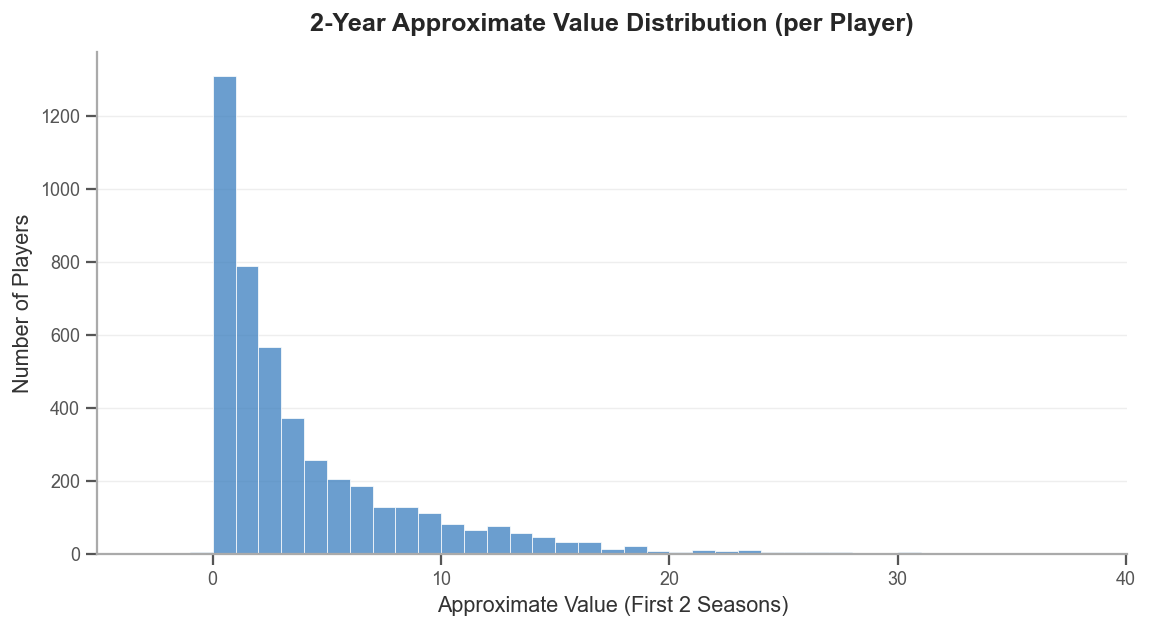

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=summed_av,
    x='AV',
    bins=np.arange(summed_av['AV'].min(), summed_av['AV'].max() + 2),
    color="#3A7EBF",
    edgecolor="white",
    linewidth=0.4,
    ax=ax,
)

ax.set_title("2-Year Approximate Value Distribution (per Player)")
ax.set_xlabel("Approximate Value (First 2 Seasons)")
ax.set_ylabel("Number of Players")
ax.yaxis.grid(True)
ax.set_axisbelow(True)
sns.despine()

plt.tight_layout()
plt.show()

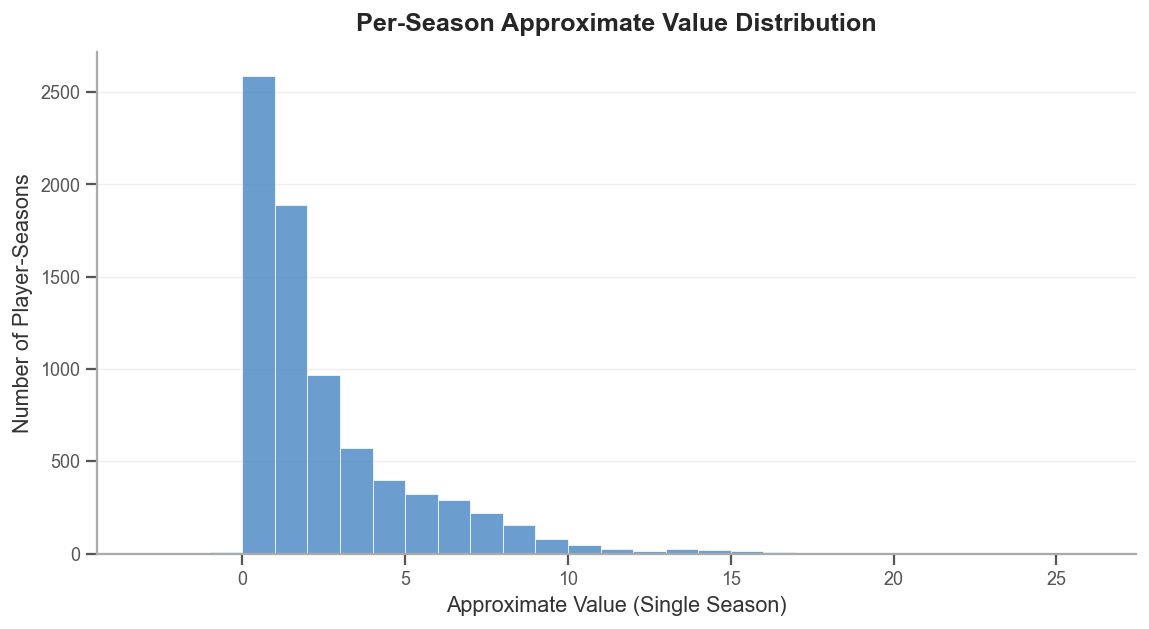

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=combined,
    x='AV',
    bins=np.arange(combined['AV'].min(), combined['AV'].max() + 2),
    color="#3A7EBF",
    edgecolor="white",
    linewidth=0.4,
    ax=ax,
)

ax.set_title("Per-Season Approximate Value Distribution")
ax.set_xlabel("Approximate Value (Single Season)")
ax.set_ylabel("Number of Player-Seasons")
ax.yaxis.grid(True)
ax.set_axisbelow(True)
sns.despine()

plt.tight_layout()
plt.show()